#### Cycle-Aware Diagram

This diagram was created to visually summarise menstrual cycle phases, hormonal fluctuations, and possible impacts on training and fatigue. The information used to create this visualisation was adapted from menstrual cycle and athletic performance research, including Carmichael et al. (2021).
https://www.mdpi.com/1660-4601/18/4/1667

In [2]:
%pip install notebook matplotlib numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


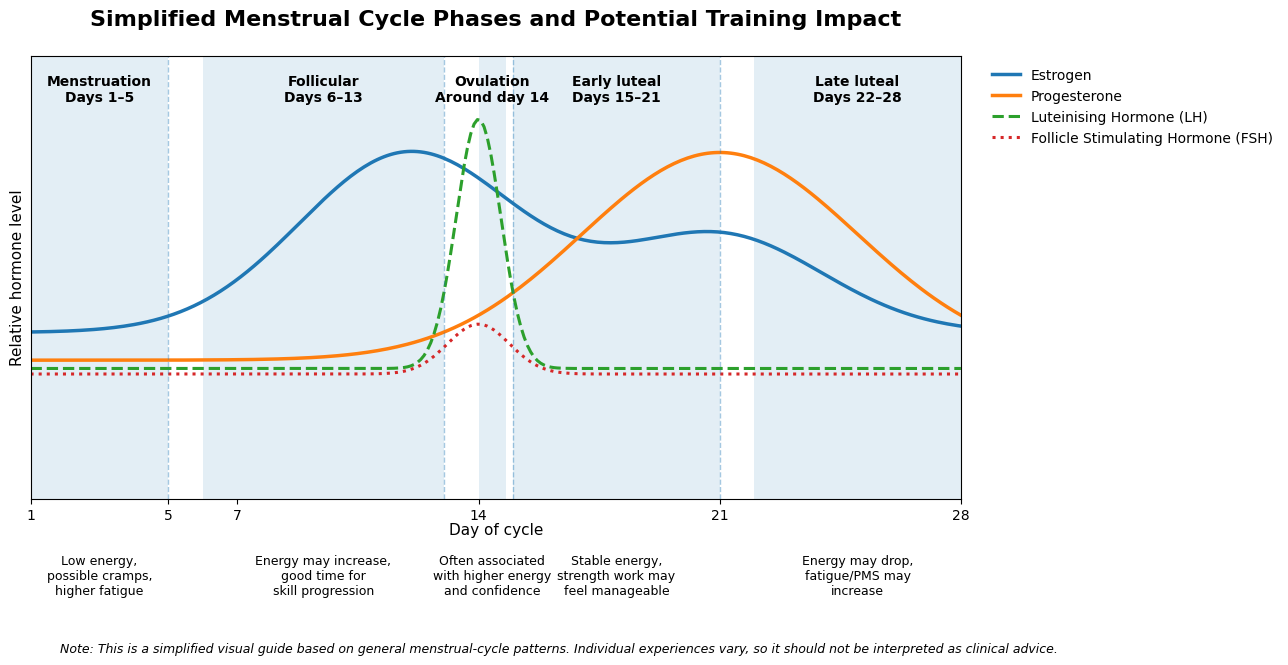

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# create a simplified 28 day cycle
days = np.linspace(1, 28, 280)

# simplified hormone curves
# these are visual approximations, not exact medical data

# estrogen rises during the follicular phase,
# peaks around ovulation, then has a smaller second rise later
estrogen = (
    0.25
    + 0.65 * np.exp(-0.5 * ((days - 12) / 3.2) ** 2)
    + 0.35 * np.exp(-0.5 * ((days - 21) / 3.0) ** 2)
)

# progesterone mainly rises after ovulation
progesterone = (
    0.15
    + 0.75 * np.exp(-0.5 * ((days - 21) / 4.0) ** 2)
)

# luteinising hormone spike around ovulation
lh = (
    0.12
    + 0.9 * np.exp(-0.5 * ((days - 14) / 0.65) ** 2)
)

# smaller follicle stimulating hormone spike
fsh = (
    0.10
    + 0.18 * np.exp(-0.5 * ((days - 14) / 0.9) ** 2)
)

# create the figure and graph area
fig, ax = plt.subplots(figsize=(13, 7))

# cycle phase sections
# each tuple stores:
# start day, end day, title, short description

phases = [
    (
        1,
        5,
        "Menstruation\nDays 1–5",
        "Low energy,\npossible cramps,\nhigher fatigue",
    ),
    (
        6,
        13,
        "Follicular\nDays 6–13",
        "Energy may increase,\ngood time for\nskill progression",
    ),
    (
        14,
        14.8,
        "Ovulation\nAround day 14",
        "Often associated\nwith higher energy\nand confidence",
    ),
    (
        15,
        21,
        "Early luteal\nDays 15–21",
        "Stable energy,\nstrength work may\nfeel manageable",
    ),
    (
        22,
        28,
        "Late luteal\nDays 22–28",
        "Energy may drop,\nfatigue/PMS may\nincrease",
    ),
]

# loop through each phase and draw the background area + labels
for start, end, title, note in phases:

    # shaded phase background
    ax.axvspan(start, end, alpha=0.12)

    # phase title at the top
    ax.text(
        (start + end) / 2,
        1.13,
        title,
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
    )

    # phase notes at the bottom
    ax.text(
        (start + end) / 2,
        -0.55,
        note,
        ha="center",
        va="top",
        fontsize=9,
        wrap=True,
    )

# draw hormone curves
ax.plot(days, estrogen, label="Estrogen", linewidth=2.5)

ax.plot(days, progesterone, label="Progesterone", linewidth=2.5)

ax.plot(
    days,
    lh,
    label="Luteinising Hormone (LH)",
    linewidth=2.2,
    linestyle="--",
)

ax.plot(
    days,
    fsh,
    label="Follicle Stimulating Hormone (FSH)",
    linewidth=2.2,
    linestyle=":",
)

# phase divider lines
for x in [5, 13, 15, 21]:
    ax.axvline(x, linewidth=1, linestyle="--", alpha=0.4)

# graph title
ax.set_title(
    "Simplified Menstrual Cycle Phases and Potential Training Impact",
    fontsize=16,
    fontweight="bold",
    pad=22,
)

# axis labels
ax.set_xlabel("Day of cycle", fontsize=11, labelpad=0)
ax.set_ylabel("Relative hormone level", fontsize=11)

# graph ranges
ax.set_xlim(1, 28)
ax.set_ylim(-0.35, 1.25)

# x axis markers
ax.set_xticks([1, 5, 7, 14, 21, 28])

# hide y axis values because the graph is illustrative
ax.set_yticks([])

# add hormone legend
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=False,
)

# small note underneath the graph
fig.text(
    0.05,
    0.02,
    "Note: This is a simplified visual guide based on general menstrual-cycle patterns. "
    "Individual experiences vary, so it should not be interpreted as clinical advice.",
    fontsize=9,
    style="italic",
)

# tidy layout spacing
plt.tight_layout(rect=[0, 0.06, 1, 0.96])

# save image for thesis use
plt.savefig(
    "menstrual_cycle_diagram.png",
    dpi=300,
    bbox_inches="tight",
)

# show graph window
plt.show()